# PARSeq fine-tuned original error sheet

Notebook nay lay cac bien so ma model PARSeq fine-tuned goc da eval sai tu pipeline goc:

`D:/NEO/LPR/parseq_official_pipeline/outputs/refinement_finetune`

No se tao mot errors sheet de xem nhanh: moi card gom anh bien so va bang thong tin ben duoi gom `image_path`, `GT`, `PR`, `edit_distance`, `confidence`.


In [16]:
from pathlib import Path
import base64
import html
import os
import re

import pandas as pd
from PIL import Image, ImageDraw
from IPython.display import HTML, display

# Source goc cua model fine-tuned va file eval output.
SOURCE_REFINE_DIR = Path(r'D:/NEO/LPR/parseq_official_pipeline/outputs/refinement_finetune')
SPLIT = 'test'  # doi thanh 'val' neu muon xem validation errors
PRED_CSV = SOURCE_REFINE_DIR / f'eval_{SPLIT}_predictions_best_refine.csv'

# Output gom rieng mot cho trong workspace hien tai de tranh lan voi pipeline goc.
WORKSPACE_DIR = Path.cwd()
if (WORKSPACE_DIR / 'parseq_rl_deblur_data').exists():
    WORKSPACE_DIR = WORKSPACE_DIR / 'parseq_rl_deblur_data'
OUT_DIR = WORKSPACE_DIR / 'outputs' / 'refinement_finetune' / 'error_analysis_from_original' / SPLIT
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Mapping cot trong CSV goc. Trong eval_*_predictions_best_refine.csv: target = GT, prediction = PR.
GT_COL = 'target'
PRED_COL = 'prediction'
IMAGE_PATH_COL = 'image_path'

print('source refine dir:', SOURCE_REFINE_DIR)
print('prediction csv:', PRED_CSV)
print('output dir:', OUT_DIR)
print('GT column:', GT_COL)
print('PR column:', PRED_COL)


source refine dir: D:\NEO\LPR\parseq_official_pipeline\outputs\refinement_finetune
prediction csv: D:\NEO\LPR\parseq_official_pipeline\outputs\refinement_finetune\eval_test_predictions_best_refine.csv
output dir: d:\NEO\rl_pipeline\parseq_rl_deblur_data\outputs\refinement_finetune\error_analysis_from_original\test
GT column: target
PR column: prediction


In [17]:
df = pd.read_csv(PRED_CSV)

required_cols = {IMAGE_PATH_COL, GT_COL, PRED_COL, 'exact', 'edit_distance', 'confidence'}
missing = sorted(required_cols - set(df.columns))
if missing:
    raise KeyError(f'Thieu cot trong prediction CSV: {missing}')

if df['exact'].dtype != bool:
    df['exact'] = df['exact'].astype(str).str.lower().isin(['true', '1', 'yes'])

def image_name_from_path(value):
    # Ho tro ca Windows path khi notebook chay tren Linux/Colab.
    parts = re.split(r'[\\/]+', str(value))
    return parts[-1] if parts else str(value)

df['image_name'] = df[IMAGE_PATH_COL].map(image_name_from_path)
df['gt_text'] = df[GT_COL].astype(str).str.upper()
df['pred_text'] = df[PRED_COL].astype(str).str.upper()
df['cer'] = df['edit_distance'] / df['gt_text'].str.len().clip(lower=1)
df['image_exists'] = df[IMAGE_PATH_COL].map(lambda p: Path(str(p)).exists())

errors = df.loc[~df['exact']].copy().reset_index(drop=True)
errors = errors.sort_values(['edit_distance', 'confidence'], ascending=[False, False]).reset_index(drop=True)
errors.insert(0, 'error_rank', range(1, len(errors) + 1))

front_cols = [
    'error_rank', 'image_name', IMAGE_PATH_COL, 'image_exists',
    'gt_text', 'pred_text', GT_COL, PRED_COL,
    'exact', 'edit_distance', 'cer', 'confidence',
    'split', 'source_name', 'plate_type', 'label_status', 'review_status',
]
front_cols = [c for c in front_cols if c in errors.columns]
other_cols = [c for c in errors.columns if c not in front_cols]
errors = errors[front_cols + other_cols]

errors_csv = OUT_DIR / f'parseq_finetune_original_{SPLIT}_errors.csv'
errors.to_csv(errors_csv, index=False, encoding='utf-8-sig')

summary = pd.DataFrame([{
    'source_csv': str(PRED_CSV),
    'split': SPLIT,
    'samples': len(df),
    'errors': len(errors),
    'exact_acc': float(df['exact'].mean()),
    'cer': float(df['cer'].mean()),
    'error_images_found': int(errors['image_exists'].sum()),
    'error_images_missing': int((~errors['image_exists']).sum()),
    'errors_csv': str(errors_csv),
}])
display(summary)
display(errors[['error_rank', 'image_name', IMAGE_PATH_COL, 'gt_text', 'pred_text', 'edit_distance', 'cer', 'confidence', 'image_exists']].head(30))
print('saved csv:', errors_csv)


,source_csv,split,samples,errors,exact_acc,cer,error_images_found,error_images_missing,errors_csv
0,D:\NEO\LPR\parseq_official_pipeline\outputs\re...,test,963,54,0.943925,0.009236,54,0,d:\NEO\rl_pipeline\parseq_rl_deblur_data\outpu...


,error_rank,image_name,image_path,gt_text,pred_text,edit_distance,cer,confidence,image_exists
0,1,Dieu_0174_p01.png,d:\NEO\LPR\ocr_dataset_rescued_bbox_new\images...,959K193,59X194293,5,0.714286,0.998467,True
1,2,carlong_0449_p01.png,d:\NEO\LPR\ocr_dataset_rescued_bbox_new\images...,51F65B5,51F15585,3,0.428571,0.623533,True
2,3,Hung_0105_p01.png,d:\NEO\LPR\ocr_dataset_rescued_bbox_new\images...,59X189097,59X180997,2,0.222222,0.994803,True
3,4,greenpack_1424_p01.png,d:\NEO\LPR\ocr_dataset_rescued_bbox_new\images...,51L3D352,51L0352,2,0.250000,0.989567,True
4,5,greenpack_1530_p01.png,d:\NEO\LPR\ocr_dataset_rescued_bbox_new\images...,69B132267,9B1332267,2,0.222222,0.939605,True
5,6,Hung_0136_p01.png,d:\NEO\LPR\ocr_dataset_rescued_bbox_new\images...,83371552,83P321552,2,0.250000,0.909293,True
6,7,Hung_0029_p02_02.png,d:\NEO\LPR\baseline_icpr_2026\color_filtered\o...,60F177396,60F127395,2,0.222222,0.828660,True
7,8,Dieu_0221_p01.png,d:\NEO\LPR\ocr_dataset_rescued_bbox_new\images...,67H00945,57H00946,2,0.250000,0.820135,True
8,9,greenpack_0486_p01.png,d:\NEO\LPR\ocr_dataset_rescued_bbox_new\images...,B537011,AYB537011,2,0.285714,0.568582,True
9,10,greenpack_0486_p01_01.png,d:\NEO\LPR\baseline_icpr_2026\color_filtered\o...,B537011,AYB537011,2,0.285714,0.568582,True


saved csv: d:\NEO\rl_pipeline\parseq_rl_deblur_data\outputs\refinement_finetune\error_analysis_from_original\test\parseq_finetune_original_test_errors.csv


In [18]:
# Thong ke theo nhom de xem loi tap trung o dau.
group_cols = [c for c in ['source_name', 'plate_type', 'label_status', 'review_status'] if c in df.columns]
stats = []
for col in group_cols:
    g = df.groupby(col, dropna=False).agg(
        samples=('exact', 'size'),
        errors=('exact', lambda s: int((~s).sum())),
        exact_acc=('exact', 'mean'),
        cer=('cer', 'mean'),
        mean_confidence=('confidence', 'mean'),
    ).reset_index()
    g.insert(0, 'group_by', col)
    g = g.rename(columns={col: 'group_value'})
    stats.append(g)

stats_df = pd.concat(stats, ignore_index=True) if stats else pd.DataFrame()
if not stats_df.empty:
    stats_df = stats_df.sort_values(['group_by', 'errors'], ascending=[True, False])
stats_csv = OUT_DIR / f'parseq_finetune_original_{SPLIT}_error_stats_by_group.csv'
stats_df.to_csv(stats_csv, index=False, encoding='utf-8-sig')
display(stats_df)
print('saved stats:', stats_csv)


,group_by,group_value,samples,errors,exact_acc,cer,mean_confidence
12,label_status,prepared,552,36,0.934783,0.011100,0.981827
11,label_status,labels_txt,368,13,0.964674,0.005074,0.979627
10,label_status,corrected,43,5,0.883721,0.020930,0.941225
6,plate_type,normal,552,36,0.934783,0.011100,0.981827
7,plate_type,other,355,10,0.971831,0.004102,0.981479
8,plate_type,quandoi,38,5,0.868421,0.023684,0.934993
9,plate_type,yellow,12,3,0.750000,0.034226,0.925306
4,plate_type,blue,1,0,1.000000,0.000000,0.974290
5,plate_type,ngoaigiao,5,0,1.000000,0.000000,0.988590
15,review_status,prepared,552,36,0.934783,0.011100,0.981827


saved stats: d:\NEO\rl_pipeline\parseq_rl_deblur_data\outputs\refinement_finetune\error_analysis_from_original\test\parseq_finetune_original_test_error_stats_by_group.csv


saved html sheet: d:\NEO\rl_pipeline\parseq_rl_deblur_data\outputs\refinement_finetune\error_analysis_from_original\test\parseq_finetune_original_test_errors_sheet.html


Image path,d:\NEO\LPR\ocr_dataset_rescued_bbox_new\images\test\Dieu_0174_p01.png
GT,959K193
PR,59X194293
Edit / CER,5 / 0.7143
Confidence,0.998467
Source / Type,vietnam_normal / normal
Image path,d:\NEO\LPR\ocr_dataset_rescued_bbox_new\images\test\carlong_0449_p01.png
GT,51F65B5
PR,51F15585
Edit / CER,3 / 0.4286
Confidence,0.623533

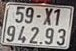
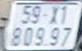
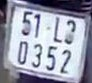
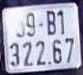
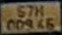
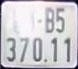
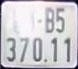
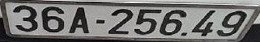
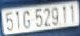
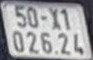
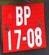
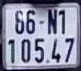
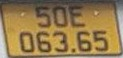
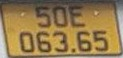
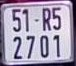
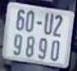
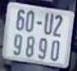
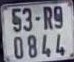
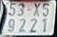
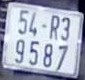
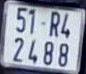
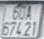
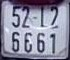
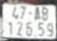
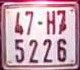
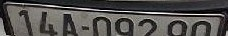
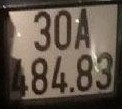
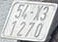
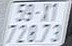
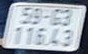
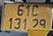
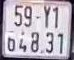
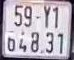
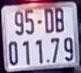
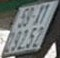
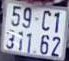
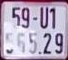
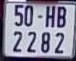
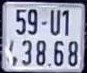
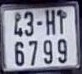
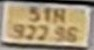
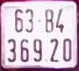
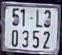
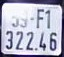
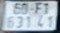

In [19]:
# Tao contact sheet dang anh + bang duoi moi anh.
# HTML duoc embed base64 nen mo lai duoc ma khong can duong dan anh con ton tai.
MAX_CARDS = None  # None = hien tat ca loi; dat 30/60 neu muon sheet nhe hon
THUMB_W = 260

def image_to_data_uri(path, max_w=THUMB_W):
    path = Path(str(path))
    if not path.exists():
        return ''
    img = Image.open(path).convert('RGB')
    if img.width > max_w:
        ratio = max_w / img.width
        img = img.resize((max_w, max(1, int(img.height * ratio))))
    tmp = OUT_DIR / '_tmp_thumb.jpg'
    img.save(tmp, format='JPEG', quality=90)
    encoded = base64.b64encode(tmp.read_bytes()).decode('ascii')
    tmp.unlink(missing_ok=True)
    return f'data:image/jpeg;base64,{encoded}'

def esc(value):
    return html.escape(str(value))

cards = []
sheet_df = errors if MAX_CARDS is None else errors.head(MAX_CARDS)
for _, row in sheet_df.iterrows():
    image_uri = image_to_data_uri(row[IMAGE_PATH_COL])
    if image_uri:
        image_html = f'<img class="plate" src="{image_uri}" />'
    else:
        image_html = '<div class="missing">missing image</div>'

    cards.append(f'''
    <section class="card">
      <div class="rank">#{int(row['error_rank'])} &nbsp; {esc(row['image_name'])}</div>
      <div class="image-wrap">{image_html}</div>
      <table>
        <tr><th>Image path</th><td class="path">{esc(row[IMAGE_PATH_COL])}</td></tr>
        <tr><th>GT</th><td class="gt">{esc(row['gt_text'])}</td></tr>
        <tr><th>PR</th><td class="pr">{esc(row['pred_text'])}</td></tr>
        <tr><th>Edit / CER</th><td>{esc(row['edit_distance'])} / {float(row['cer']):.4f}</td></tr>
        <tr><th>Confidence</th><td>{float(row['confidence']):.6f}</td></tr>
        <tr><th>Source / Type</th><td>{esc(row.get('source_name', ''))} / {esc(row.get('plate_type', ''))}</td></tr>
      </table>
    </section>
    ''')

html_doc = f'''
<!doctype html>
<html>
<head>
<meta charset="utf-8" />
<title>PARSeq fine-tuned original errors - {SPLIT}</title>
<style>
  body {{ font-family: Arial, sans-serif; margin: 20px; background: #f6f7f9; color: #111; }}
  h1 {{ margin: 0 0 6px; }}
  .meta {{ margin-bottom: 18px; color: #444; line-height: 1.45; }}
  .grid {{ display: grid; grid-template-columns: repeat(auto-fill, minmax(360px, 1fr)); gap: 16px; }}
  .card {{ background: #fff; border: 1px solid #d8dce2; border-radius: 8px; padding: 12px; box-shadow: 0 1px 2px rgba(0,0,0,.04); }}
  .rank {{ font-weight: 700; margin-bottom: 8px; }}
  .image-wrap {{ min-height: 72px; display: flex; align-items: center; justify-content: center; background: #111; border-radius: 6px; overflow: hidden; margin-bottom: 10px; }}
  img.plate {{ max-width: 100%; height: auto; image-rendering: auto; }}
  .missing {{ color: #fff; padding: 20px; }}
  table {{ width: 100%; border-collapse: collapse; font-size: 13px; }}
  th {{ width: 92px; text-align: left; color: #555; border-top: 1px solid #edf0f3; padding: 6px 6px 6px 0; vertical-align: top; }}
  td {{ border-top: 1px solid #edf0f3; padding: 6px 0; vertical-align: top; word-break: break-word; }}
  .gt {{ color: #0a7a28; font-weight: 700; }}
  .pr {{ color: #b00020; font-weight: 700; }}
  .path {{ font-family: Consolas, monospace; font-size: 12px; }}
</style>
</head>
<body>
<h1>PARSeq fine-tuned original errors - split: {SPLIT}</h1>
<div class="meta">
  Source CSV: <code>{esc(PRED_CSV)}</code><br/>
  Total samples: {len(df)} | Errors: {len(errors)} | Exact acc: {float(df['exact'].mean()):.4f} | CER: {float(df['cer'].mean()):.4f}
</div>
<div class="grid">
{''.join(cards)}
</div>
</body>
</html>
'''

sheet_html = OUT_DIR / f'parseq_finetune_original_{SPLIT}_errors_sheet.html'
sheet_html.write_text(html_doc, encoding='utf-8')
print('saved html sheet:', sheet_html)
display(HTML(html_doc))


saved contact sheet: d:\NEO\rl_pipeline\parseq_rl_deblur_data\outputs\refinement_finetune\error_analysis_from_original\test\parseq_finetune_original_test_contact_sheet.jpg


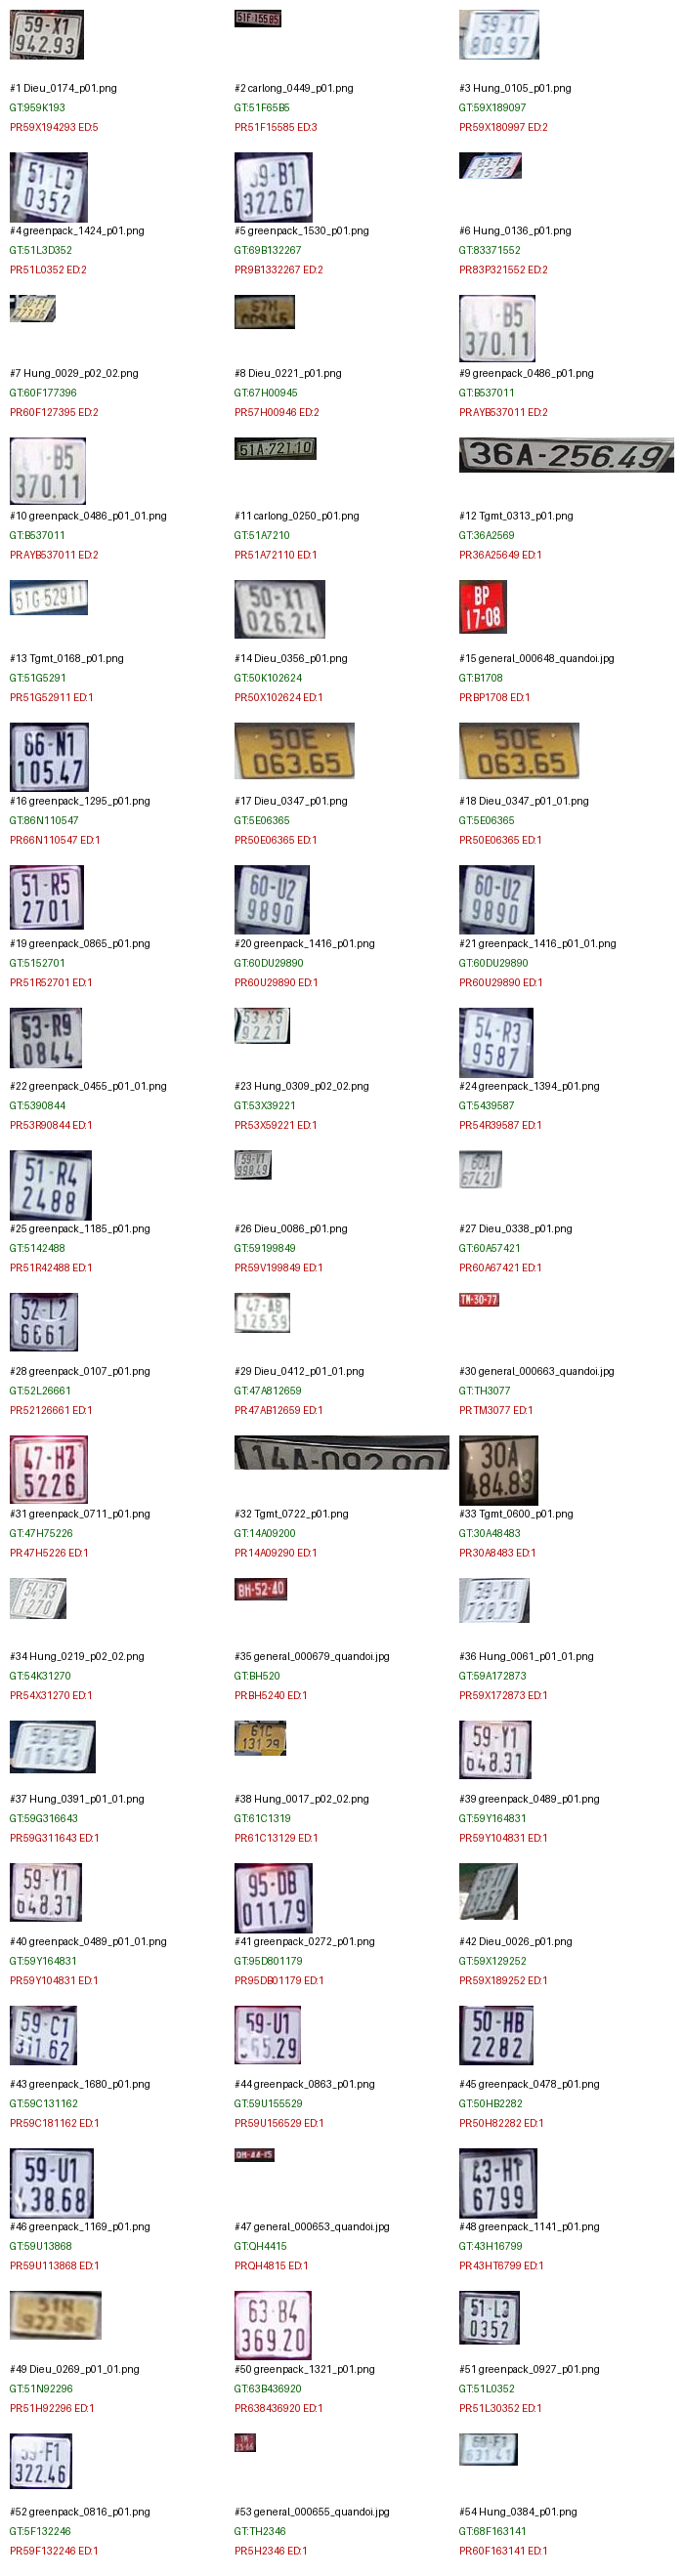

In [20]:
# Optional: tao mot anh contact sheet don gian de chen vao report.
CONTACT_SHEET_LIMIT = 80
THUMB_W, THUMB_H = 220, 72
LABEL_H = 64
PAD = 10
COLS = 3

available = errors[errors['image_exists']].head(CONTACT_SHEET_LIMIT)
if available.empty:
    print('Khong co anh nao ton tai tai image_path trong CSV.')
else:
    rows = (len(available) + COLS - 1) // COLS
    canvas = Image.new('RGB', (COLS * (THUMB_W + PAD) + PAD, rows * (THUMB_H + LABEL_H + PAD) + PAD), 'white')
    draw = ImageDraw.Draw(canvas)
    for idx, (_, row) in enumerate(available.iterrows()):
        col = idx % COLS
        rr = idx // COLS
        x = PAD + col * (THUMB_W + PAD)
        y = PAD + rr * (THUMB_H + LABEL_H + PAD)
        img = Image.open(row[IMAGE_PATH_COL]).convert('RGB')
        img.thumbnail((THUMB_W, THUMB_H))
        canvas.paste(img, (x, y))
        draw.text((x, y + THUMB_H + 2), f"#{int(row['error_rank'])} {row['image_name']}"[:34], fill=(0, 0, 0))
        draw.text((x, y + THUMB_H + 22), f"GT:{row['gt_text']}"[:34], fill=(0, 90, 0))
        draw.text((x, y + THUMB_H + 42), f"PR:{row['pred_text']} ED:{row['edit_distance']}"[:34], fill=(180, 0, 0))

    sheet_png = OUT_DIR / f'parseq_finetune_original_{SPLIT}_contact_sheet.jpg'
    canvas.save(sheet_png, quality=92)
    print('saved contact sheet:', sheet_png)
    display(canvas)
